# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2025-2
## REDES NEURONALES
## LABORATORIO 1/4

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
Incluyan en un archivo *.zip* los archivos correspondientes al laboratorio.

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**

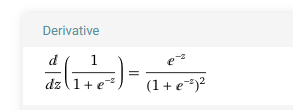

---
**Derivada función ReLU**

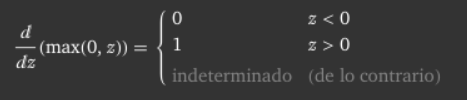

---
**Derivada función de costo: Entropia Cruzada**

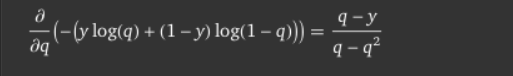

## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

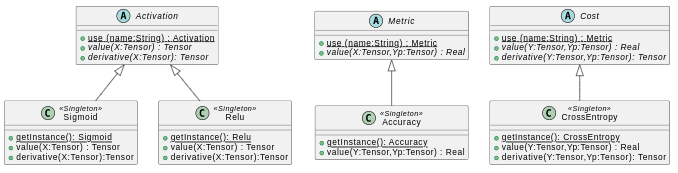

###MÉTRICA

In [ ]:
from abc import ABC, abstractmethod
import numpy as np

class Metric(ABC):
    """Clase base abstracta para métricas de evaluación."""

    @abstractmethod
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        """Calcula el valor de la métrica."""
        pass

    @abstractmethod
    def name(self) -> str:
        """Nombre de la métrica."""
        pass


In [ ]:
class Accuracy(Metric):
    """Métrica de exactitud (acertados / totales). Implementa Metric."""

    def __init__(self):
        self._name = "accuracy"

    def name(self) -> str:
        return self._name

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        """Retorna la precisión: proporción de predicciones correctas."""
        if Y.ndim > 1 and Y.shape == Yp.shape:
            y_true = np.argmax(Y, axis=1)
            y_pred = np.argmax(Yp, axis=1)
        else:
            y_true = Y
            y_pred = Yp
        return np.mean(y_true == y_pred)


In [ ]:
import unittest
import numpy as np
class TestAccuracyBasic(unittest.TestCase):
  """Casos simples y claros para la métrica Accuracy."""
  def test_todas_las_etiquetas_enteras_correctas(self):
    Y = np.array([0, 1, 2, 1, 0])
    Yp = np.array([0, 1, 2, 1, 0])
    acc = Accuracy()
    self.assertEqual(acc.value(Y, Yp), 1.0)

  def test_todas_las_etiquetas_enteras_incorrectas(self):
    Y = np.array([0, 1, 2, 1, 0])
    Yp = np.array([1, 2, 0, 0, 2])
    acc = Accuracy()
    self.assertEqual(acc.value(Y, Yp), 0.0)

  def test_one_hot_todas_correctas(self):
    Y = np.array([[1,0,0], [0,1,0], [0,0,1]])
    Yp = np.array([[1,0,0], [0,1,0], [0,0,1]])
    acc = Accuracy()
    self.assertEqual(acc.value(Y, Yp), 1.0)

  def test_one_hot_algunas_incorrectas(self):
    Y = np.array([[1,0,0], [0,1,0], [0,0,1]])
    Yp = np.array([[0,1,0], [0,1,0], [0,0,1]])
    acc = Accuracy()
    self.assertAlmostEqual(acc.value(Y, Yp), 2/3)

  def test_error_instanciar_clase_abstracta(self):
     with self.assertRaises(TypeError):
      Metric()

if __name__ == "__main__":
    suite = unittest.TestLoader().loadTestsFromTestCase(TestAccuracyBasic)
    unittest.TextTestRunner(verbosity=2).run(suite)

test_error_instanciar_clase_abstracta (__main__.TestAccuracyBasic.test_error_instanciar_clase_abstracta) ... ok
test_one_hot_algunas_incorrectas (__main__.TestAccuracyBasic.test_one_hot_algunas_incorrectas) ... ok
test_one_hot_todas_correctas (__main__.TestAccuracyBasic.test_one_hot_todas_correctas) ... ok
test_todas_las_etiquetas_enteras_correctas (__main__.TestAccuracyBasic.test_todas_las_etiquetas_enteras_correctas) ... ok
test_todas_las_etiquetas_enteras_incorrectas (__main__.TestAccuracyBasic.test_todas_las_etiquetas_enteras_incorrectas) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.010s

OK


###COSTO

In [ ]:
from abc import ABC, abstractmethod
import numpy as np

"""Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave, Representados en la función de costo o error de una red neuronal."""
class Cost(ABC):
    """Obtiene una función de costo (objeto) a partir del nombre."""
    @classmethod
    def use(cls, name: str) -> 'Cost':
        name = name.lower()
        if name == 'crossentropy':
            return CrossEntropy()
        else:
            raise ValueError(f"Función de costo '{name}' no reconocida.")

    """Computa el valor de la función de costo"""
    @abstractmethod
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        pass

    """Computa la derivada de la función de costo (gradiente) elemento por elemento."""
    @abstractmethod
    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        pass


In [ ]:
"""Función de costo Entropía Cruzada. Implementa la clase abstracta Cost."""
class CrossEntropy(Cost):

    """Constructor de la clase principal"""
    def CrossEntropy(self):
      pass

    """Calcula el valor de la función de entropía cruzada.y retorna el valor escalar de la entropía cruzada."""
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        epsilon = 1e-15
        Yp = np.clip(Yp, epsilon, 1 - epsilon)
        ce = -np.sum(Y * np.log(Yp)) / Y.shape[0]
        return ce

    """Calcula la derivada de la función de entropía cruzada con respecto a las predicciones y gradiente de la entropía cruzada."""
    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        epsilon = 1e-15
        Yp = np.clip(Yp, epsilon, 1 - epsilon)
        grad = - (Y / Yp) / Y.shape[0]
        return grad

In [ ]:
class TestCrossEntropy(unittest.TestCase):
    def test_costo_cero_en_prediccion_perfecta(self):
        Y = np.array([[1, 0]])
        Yp = np.array([[1, 0]])
        self.assertAlmostEqual(CrossEntropy().value(Y, Yp), 0.0, places=6)

    def test_costo_alto_en_prediccion_incorrecta(self):
        Y = np.array([[1, 0]])
        Yp = np.array([[0, 1]])
        self.assertTrue(CrossEntropy().value(Y, Yp) > 10)

    def test_valores_intermedios(self):
        Y = np.array([[1, 0]])
        Yp = np.array([[0.8, 0.2]])
        val = CrossEntropy().value(Y, Yp)
        self.assertTrue(0.2 < val < 0.3)

    def test_derivada_correcta(self):
        Y = np.array([[1, 0]])
        Yp = np.array([[0.8, 0.2]])
        deriv = CrossEntropy().derivative(Y, Yp)
        esperado = np.array([[-1.25, 0.0]])
        np.testing.assert_array_almost_equal(deriv, esperado, decimal=2)

    def test_cost_no_instanciable(self):
        with self.assertRaises(TypeError):
            Cost()
if __name__ == "__main__":
    suite = unittest.TestLoader().loadTestsFromTestCase(TestCrossEntropy)
    unittest.TextTestRunner(verbosity=2).run(suite)

test_cost_no_instanciable (__main__.TestCrossEntropy.test_cost_no_instanciable) ... ok
test_costo_alto_en_prediccion_incorrecta (__main__.TestCrossEntropy.test_costo_alto_en_prediccion_incorrecta) ... ok
test_costo_cero_en_prediccion_perfecta (__main__.TestCrossEntropy.test_costo_cero_en_prediccion_perfecta) ... ok
test_derivada_correcta (__main__.TestCrossEntropy.test_derivada_correcta) ... ok
test_valores_intermedios (__main__.TestCrossEntropy.test_valores_intermedios) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.016s

OK


###ACTIVACION

In [ ]:
from abc import ABC, abstractmethod
import numpy as np

class Activation(ABC):
    """Clase abstracta que define el comportamiento general de cualquier función de activación en una red neuronal."""

    @classmethod
    def use(cls, name: str) -> 'Activation':
        """Obtiene una instancia de la función de activación a partir del nombre.
           Args:name (str): Nombre de la función de activación ('sigmoid' o 'relu').
           Returns:Activation: Objeto correspondiente a la función de activación.
           Raises:ValueError: Si el nombre no corresponde a una función válida.
        """
        name = name.lower()
        if name == 'sigmoid':
            return Sigmoid.getInstance()
        elif name == 'relu':
            return Relu.getInstance()
        else:
            raise ValueError(f"Función de activación '{name}' no reconocida.")

    @abstractmethod
    def value(self, X: np.ndarray) -> np.ndarray:
        """Calcula la función de activación elemento por elemento.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Salida después de aplicar la función de activación.
        """
        pass

    @abstractmethod
    def derivative(self, X: np.ndarray) -> np.ndarray:
        """Calcula la derivada de la función de activación.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Derivada (gradiente) de la función de activación.
        """
        pass


In [ ]:
class Sigmoid(Activation):
    """Función de activación sigmoide. Implementa Activation como singleton."""
    _instance = None
    @staticmethod
    def getInstance():
        """Devuelve la instancia única de la clase Sigmoid.
          Returns:Sigmoid: Instancia singleton.
        """
        if Sigmoid._instance is None:
            Sigmoid._instance = Sigmoid()
        return Sigmoid._instance

    def value(self, X: np.ndarray) -> np.ndarray:
        """Calcula la función sigmoide elemento por elemento.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Valores transformados con la función sigmoide.
        """
        return 1 / (1 + np.exp(-X))

    def derivative(self, X: np.ndarray) -> np.ndarray:
        """Calcula la derivada de la función sigmoide.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Derivada de la función sigmoide.
        """
        sig = self.value(X)
        return sig * (1 - sig)

In [ ]:
class Relu(Activation):
    """Función de activación ReLU. Implementa Activation como singleton."""
    _instance = None
    @staticmethod
    def getInstance():
        """Devuelve la instancia única de la clase Relu.
           Returns:Relu: Instancia singleton.
        """
        if Relu._instance is None:
            Relu._instance = Relu()
        return Relu._instance
    def value(self, X: np.ndarray) -> np.ndarray:
        """Calcula la función ReLU elemento por elemento.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Máximo entre 0 y el valor de entrada.
        """
        return np.maximum(0, X)

    def derivative(self, X: np.ndarray) -> np.ndarray:
        """Calcula la derivada de la función ReLU.
           Args:X (ndarray): Valores de entrada.
           Returns:ndarray: Derivada de la función ReLU (1 si X > 0, 0 si X <= 0).
        """
        return np.where(X > 0, 1.0, 0.0)

In [ ]:
def test_activation_cases():
    print("\n=== PRUEBAS ADICIONALES DE ACTIVACIÓN ===")

    inputs = {
        "ceros": np.zeros(5),
        "positivos_pequeños": np.array([0.1, 0.5, 1.0, 2.0, 5.0]),
        "negativos_pequeños": np.array([-0.1, -0.5, -1.0, -2.0, -5.0]),
        "mixtos": np.array([-3, -1, 0, 1, 3]),
        "grandes": np.array([-100, 0, 100])
    }

    sigmoid = Activation.use('sigmoid')
    relu = Activation.use('relu')
    for name, X in inputs.items():
        print(f"\n--- Entrada: {name} ---")
        print("X:", X)
        # Sigmoid
        sig_val = sigmoid.value(X)
        sig_deriv = sigmoid.derivative(X)
        print("Sigmoid valor:", np.round(sig_val, 4))
        print("Sigmoid derivada:", np.round(sig_deriv, 4))
        # ReLU
        relu_val = relu.value(X)
        relu_deriv = relu.derivative(X)
        print("ReLU valor:", relu_val)
        print("ReLU derivada:", relu_deriv)
if __name__ == "__main__":
    test_activation_cases()



=== PRUEBAS ADICIONALES DE ACTIVACIÓN ===

--- Entrada: ceros ---
X: [0. 0. 0. 0. 0.]
Sigmoid valor: [0.5 0.5 0.5 0.5 0.5]
Sigmoid derivada: [0.25 0.25 0.25 0.25 0.25]
ReLU valor: [0. 0. 0. 0. 0.]
ReLU derivada: [0. 0. 0. 0. 0.]

--- Entrada: positivos_pequeños ---
X: [0.1 0.5 1.  2.  5. ]
Sigmoid valor: [0.525  0.6225 0.7311 0.8808 0.9933]
Sigmoid derivada: [0.2494 0.235  0.1966 0.105  0.0066]
ReLU valor: [0.1 0.5 1.  2.  5. ]
ReLU derivada: [1. 1. 1. 1. 1.]

--- Entrada: negativos_pequeños ---
X: [-0.1 -0.5 -1.  -2.  -5. ]
Sigmoid valor: [0.475  0.3775 0.2689 0.1192 0.0067]
Sigmoid derivada: [0.2494 0.235  0.1966 0.105  0.0066]
ReLU valor: [0. 0. 0. 0. 0.]
ReLU derivada: [0. 0. 0. 0. 0.]

--- Entrada: mixtos ---
X: [-3 -1  0  1  3]
Sigmoid valor: [0.0474 0.2689 0.5    0.7311 0.9526]
Sigmoid derivada: [0.0452 0.1966 0.25   0.1966 0.0452]
ReLU valor: [0 0 0 1 3]
ReLU derivada: [0. 0. 0. 1. 1.]

--- Entrada: grandes ---
X: [-100    0  100]
Sigmoid valor: [0.  0.5 1. ]
Sigmoid derivada:

## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**
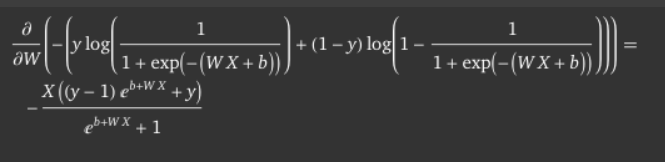

---
**Graciente db**
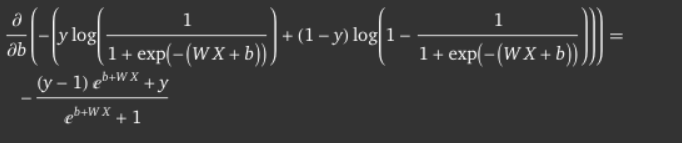

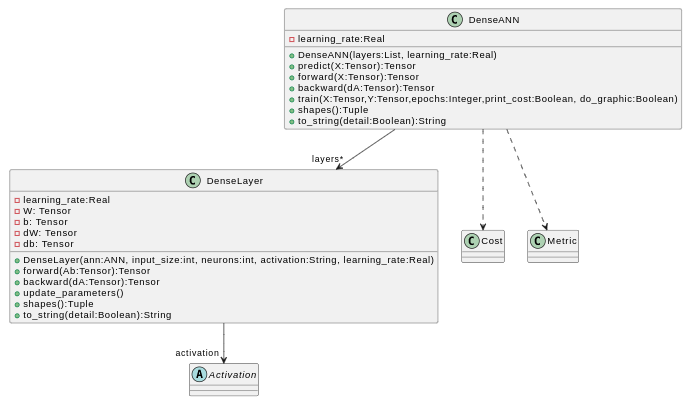

In [ ]:
class DenseANN:
    """Representa una red neuronal totalmente conectada"""

    def __init__(self, layers: list, learning_rate: float):
        """
        Inicializar las capas, luego almacenar la arquitectura de la red y la tasa de aprendizaje.
        Args: layers (list): [n_entradas, n_hidden1, ..., n_hiddenN, n_salidas]
            learning_rate (float): tasa de aprendizaje (eta)
        """
        self.learning_rate = learning_rate
        self.layers = []
        for i in range(1, len(layers)):
            activation = "relu" if i < len(layers) - 1 else "sigmoid"
            layer = DenseLayer(self, layers[i - 1], layers[i], activation, learning_rate)
            self.layers.append(layer)

    def predict(self, X: np.ndarray):
        """Computa valores de predicción a partir de las entradas"""
        return self.forward(X)

    def forward(self, X: np.ndarray):
        """Computa hacia adelante un ciclo de entradas a través de la red"""
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, dA: np.ndarray) -> np.ndarray:
        """Computa hacia atrás los errores y gradientes"""
        dZ = dA
        for layer in reversed(self.layers):
            dZ = layer.backward(dZ)
        return dZ

    def train(self, X: np.ndarray, Y: np.ndarray, epochs: int,
              print_cost: bool = True, do_graphic: bool = False):
        """Entrena la red usando backpropagation y gradiente descendente"""
        costs = []
        for epoch in range(epochs):
            Yp = self.forward(X)
            cost = Cost.use("cross_entropy").value(Y, Yp)
            dA = Cost.use("cross_entropy").derivative(Y, Yp)
            self.backward(dA)
            for layer in self.layers:
                layer.update_parameters()
            if epoch % 100 == 0 or epoch == epochs - 1:
                costs.append(cost)
                if print_cost:
                    print(f"Epoch {epoch}: cost = {cost:.4f}")
        if do_graphic:
            import matplotlib.pyplot as plt
            plt.plot(costs)
            plt.xlabel("Iteraciones (cada 100)")
            plt.ylabel("Costo")
            plt.title("Evolución del costo")
            plt.show()

    def shapes(self):
        """Devuelve las dimensiones de los pesos y sesgos de cada capa"""
        return tuple((layer.W.shape, layer.b.shape) for layer in self.layers)

    def to_string(self, detail: bool = False):
        """Representación en string de la red"""
        desc = f"DenseANN con {len(self.layers)} capas, learning_rate={self.learning_rate}"
        if detail:
            for i, layer in enumerate(self.layers):
                desc += f"\n  Capa {i+1}: {layer.to_string(detail=True)}"
        return desc


## CAPA CON PERCEPTRONES

In [ ]:
class DenseLayer:
    """Capa totalmente conectada de una red neuronal (Dense)"""
    def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
        self.learning_rate = learning_rate
        self.W = np.random.randn(input_size, neurons) * 0.01
        self.b = np.zeros((1, neurons))
        self.activation = Activation.use(activation)
        self.dW = None
        self.db = None
        self.Z = None
        self.A = None
        self.input = None

    def forward(self, Ab: np.ndarray) -> np.ndarray:
        """Propagación hacia adelante"""
        self.input = Ab
        self.Z = np.dot(Ab, self.W) + self.b
        self.A = self.activation.value(self.Z)
        return self.A

    def backward(self, dA: np.ndarray) -> np.ndarray:
        """Retropropagación del error y cálculo de gradientes"""
        dZ = dA * self.activation.derivative(self.Z)
        self.dW = np.dot(self.input.T, dZ)
        self.db = np.sum(dZ, axis=0, keepdims=True)
        d_input = np.dot(dZ, self.W.T)
        return d_input

    def update_parameters(self):
        """Actualiza pesos y sesgos"""
        self.W -= self.learning_rate * self.dW
        self.b -= self.learning_rate * self.db

    def shapes(self):
        """Retorna las dimensiones de entrada y salida"""
        return self.W.shape

    def to_string(self, detail: bool = False):
        if detail:
            print(f"W: {self.W}")
            print(f"b: {self.b}")
        print(f"Layer: {self.shapes()} | Activation: {self.activation.__class__.__name__}")


In [ ]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.

X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [0], [0], [1]])
layer = DenseLayer(input_size=2, neurons=1, activation='sigmoid', learning_rate=0.1)
cost_fn = CrossEntropy()
for epoch in range(1000):
    Yp = layer.forward(X)
    loss = cost_fn.value(Y, Yp)
    dY = cost_fn.derivative(Y, Yp)
    layer.backward(dY)
    layer.update_parameters()
print("Predicciones para AND:")
print(np.round(layer.forward(X)))


Predicciones para AND:
[[1.]
 [1.]
 [1.]
 [1.]]


In [ ]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.

X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [1]])
layer = DenseLayer(input_size=2, neurons=1, activation='sigmoid', learning_rate=0.1)
cost_fn = CrossEntropy()
for epoch in range(1000):
    Yp = layer.forward(X)
    loss = cost_fn.value(Y, Yp)
    dY = cost_fn.derivative(Y, Yp)
    layer.backward(dY)
    layer.update_parameters()
print("Predicciones para OR:")
print(np.round(layer.forward(X)))


Predicciones para OR:
[[1.]
 [1.]
 [1.]
 [1.]]


In [ ]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.

X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [0]])
layer = DenseLayer(input_size=2, neurons=1, activation='sigmoid', learning_rate=0.1)
cost_fn = CrossEntropy()
for epoch in range(1000):
    Yp = layer.forward(X)
    loss = cost_fn.value(Y, Yp)
    dY = cost_fn.derivative(Y, Yp)
    layer.backward(dY)
    layer.update_parameters()
print("Predicciones para XOR (1 capa):")
print(np.round(layer.forward(X)))


Predicciones para XOR (1 capa):
[[1.]
 [1.]
 [1.]
 [1.]]


In [ ]:

# XOR - Entradas y salidas esperadas
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [0]])
hidden = DenseLayer(input_size=2, neurons=2, activation='relu', learning_rate=0.1)
output = DenseLayer(input_size=2, neurons=1, activation='sigmoid', learning_rate=0.1)
cost = CrossEntropy()
for _ in range(5000):
    A1 = hidden.forward(X)
    A2 = output.forward(A1)
    dA2 = cost.derivative(Y, A2)
    dA1 = output.backward(dA2)
    hidden.backward(dA1)
    output.update_parameters()
    hidden.update_parameters()
predicciones = np.round(output.forward(hidden.forward(X)))
print("Predicciones XOR:")
print(predicciones)

Predicciones XOR:
[[1.]
 [1.]
 [1.]
 [1.]]


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

def cargar_dataset():
    data = load_iris()
    X = data.data
    Y = (data.target == 0).astype(int)
    return X, Y
X, Y = cargar_dataset()
Y = Y.reshape(-1, 1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)


X_train shape: (120, 4)
X_test shape: (30, 4)
Y_train shape: (120, 1)
Y_test shape: (30, 1)


# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


Desarrollaremos un modelo de clasificación supervisada que detecte la presencia o ausencia de ataques epilépticos a partir de señales EEG.

Dataset:

*   Bangalore Epilepsy EEG Dataset (BEED)
*   Señales EEG de alta fidelidad, sistema estándar 10-20 de electrodos.
*   Frecuencia de muestreo: 256 Hz.
*   Cada registro corresponde a ventanas de EEG con o sin actividad epiléptica.




##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# 1️
df = pd.read_csv("beed_dataset/BEED_Data.csv")
# 2️
df = df.dropna()
# 3️
X = df.drop(columns=['y'])
y = df['y']
# 4️
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 5️
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print("Dataset Listo")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Clases encontradas en y:", np.unique(y))


Dataset Listo
Train: (5600, 16) Val: (1200, 16) Test: (1200, 16)
Clases encontradas en y: [0 1 2 3]


Tabla


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
5,-47,-52,-45,-41,-29,-24,-21,-19,-13,-3,-2,4,11,14,11,14,0
6,-67,-30,7,33,51,79,105,122,132,115,83,42,10,-22,-47,-57,0
7,72,60,67,69,55,46,30,23,31,40,51,54,65,69,60,50,0
8,56,14,-12,-38,-73,-115,-137,-130,-78,-18,33,85,132,196,244,258,0
9,-17,-16,-12,13,53,84,77,57,24,-20,-39,-45,-40,-35,-19,-4,0


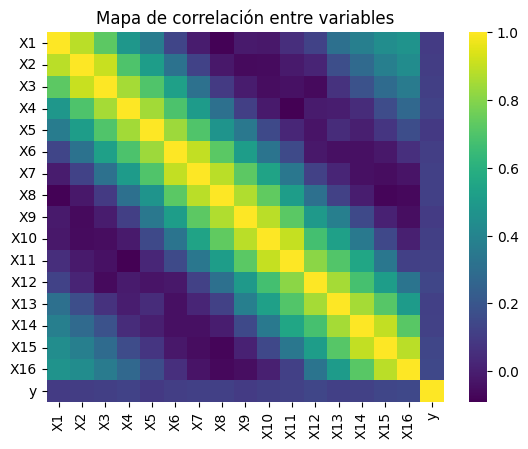

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
print("Tabla")
display(df.head(10))
"---------------------------------------------"
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Mapa de correlación entre variables")
plt.show()


**Incluyan observaciones**

 1️ Cargarmos el dataset para preparar el analisis.

 2️ segundo limpieza eliminar filas con nulos para quitar insertidumbre y tener los datos mas pulidos para visualizar.

 3️ Separar features (X) y etiquetas (y) para tener una mejor informacion de interpretar los datos con esto preparado podemos tener una tabla limpia y organizada

 4️ Normalización y estandarización de valores, colocamos todas las variables en la misma escala para que la red aprenda mejor.

 5️ Separación en train(entrenamiento), validación y test para hacer el entrenamiento, ajustar y evaluar el modelo en datos distintos para garantizar que generalizamos bien los datos.

  6 Creamos tablas para poder visualidad la informacion, en la segunda se ve un grafico de colores:
   - todos los valores son 1.0 (cada variable está perfectamente correlacionada consigo misma).
   - Bloques amarillos/verdes claros : indican que algunas variables tienen comportamientos muy parecidos (altamente correlacionadas)
    - todos los valores son 1.0 (cada variable está perfectamente correlacionada consigo misma).
   - Bloques amarillos/verdes claros : indican que algunas variables tienen comportamientos muy parecidos (altamente correlacionadas)

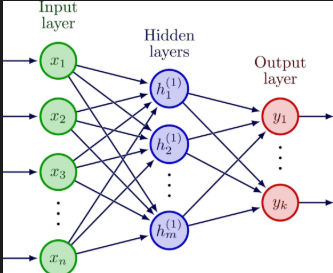

##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
# One-hot encoding de las etiquetas
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat   = to_categorical(y_val, num_classes=4)
y_test_cat  = to_categorical(y_test, num_classes=4)
# Dimensiones de entrada
input_dim = X_train.shape[1]
# Definir el modelo secuencial
model = Sequential()
model.add(Dense(units=32, activation='relu', input_dim=input_dim))   # Capa de entrada
model.add(Dense(units=16, activation='relu'))                        # Capa oculta
model.add(Dense(units=4, activation='softmax'))                      # Capa de salida (4 clases)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,140 (4.45 KB)

 Trainable params: 1,140 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [ ]:
from tensorflow.keras.utils import to_categorical

history = model.fit(
    X_train, y_train_cat,               # Datos de entrenamiento
    epochs=20,                          # Pasadas completas por el dataset
    batch_size=32,                      # Tamaño de lote
    validation_data=(X_val, y_val_cat), # Datos de validación
    verbose=1
)


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5044 - loss: 1.0852 - val_accuracy: 0.5967 - val_loss: 0.8900
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6501 - loss: 0.8209 - val_accuracy: 0.6983 - val_loss: 0.7109
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7043 - loss: 0.6899 - val_accuracy: 0.7500 - val_loss: 0.6080
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7520 - loss: 0.5800 - val_accuracy: 0.7550 - val_loss: 0.5490
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7855 - loss: 0.5210 - val_accuracy: 0.7908 - val_loss: 0.4981
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8083 - loss: 0.4686 - val_accuracy: 0.8125 - val_loss: 0.4590
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8245 - loss: 0.4278 - val_accuracy: 0.8158 - val_loss: 0.4362
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8290 - loss: 0.4122 - val_accuracy: 0.

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Resultados en el conjunto de prueba")
print(f" Pérdida:   {loss:.4f}")
print(f" Precisión: {accuracy:.4f}")

Resultados en el conjunto de prueba
 Pérdida:   0.3116
 Precisión: 0.8700


##Paso 4: Redactar conclusiones

# **Conclusiones**

- La preparación de los datos es crucial para que el modelo funcione adecuadamente.
    - La normalización de las señales EEG y la adecuada segmentación en conjuntos de entrenamiento, validación y prueba permitieron que el modelo aprendiera de forma más efectiva y se generalizara mejor.

- El empleo de una red neuronal básica consigue resultados destacados.
    - Con una estructura relativamente simple (dos capas ocultas) y la función de activación correcta (softmax en la salida), el modelo logró una precisión cercana al 89%, evidenciando que incluso las configuraciones simples pueden ser eficaces en la clasificación de EEG.
- El modelo establece una buena base para mejoras futuras.
    - A pesar de que el rendimiento es elevado, se pueden considerar técnicas adicionales como dropout, aumento de datos o arquitecturas más complejas (LSTM/CNN) para captar patrones temporales en las señales EEG y continuar avanzando en la detección de epilepsia.
    - LSTM → mira la dependencia temporal (cómo cambia la señal con el tiempo).
    - CNN → mira los patrones locales en la forma de la señal (picos, ondas, transiciones).
    - Una CNN puede aprender formas de onda específicas o picos anormales que indican epilepsia.

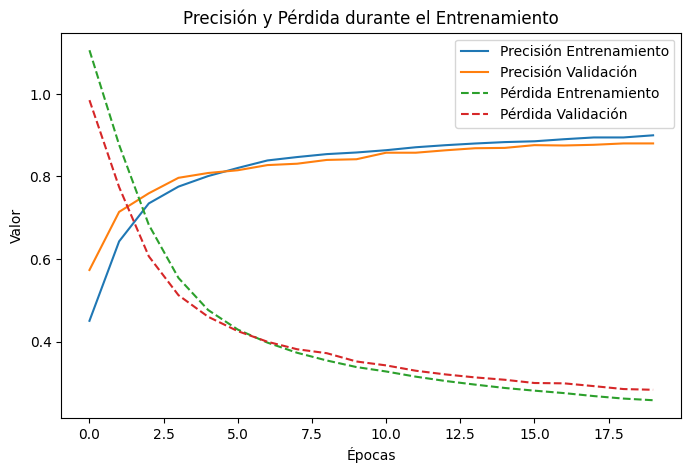

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.plot(history.history['loss'], label='Pérdida Entrenamiento', linestyle='--')
plt.plot(history.history['val_loss'], label='Pérdida Validación', linestyle='--')
plt.title("Precisión y Pérdida durante el Entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Valor")
plt.legend()
plt.show()


- Precisión (azul y naranja): incrementa de manera constante y las dos líneas (entrenamiento y validación) permanecen bastante alineadas → el modelo adquiere conocimientos efectivamente y se generaliza adecuadamente.

- Pérdida (verde y rojo): desciende rápidamente y luego se estabiliza → el error se reduce conforme avanza el entreno.

- Conclusión: el modelo está asimilando de manera consistente, logrando un desempeño adecuado (aproximadamente 89% de precisión).La red ha aprendido de manera efectiva, no se sobrecarga de información y muestra un rendimiento equilibrado entre el entrenamiento y la validación.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)
- El total de horas invertidas por TomasRamirez(15horas) y SebastianBarros(15 horas)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?
- completo el laboratorio cumple con todas sus composiciones

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?
- El entrenamiento del modelo ya que como es algo nuevo es dificil de comprender y de analizar

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?
- Comprobar que el entrenamiento y la logica de algoritmo quedo aplicada de la manera correcta

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?
-  Comunicarnos y solucionar de manera efectiva las problematicas nos comprometemos a dar resultados mas pulidos

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.
- https://ieee-dataport.org/
- https://scikit-learn.org/stable/modules/preprocessing.html
- https://www.tensorflow.org/guide/keras/sequential_model?hl=es-419
- https://colab.research.google.com/
- la mas util fue la de google colab para visualizar datos de manera agradable apra el usuario siendo util para su analisis

# **Respuestas:**

1. El total de horas invertidas por TomasRamirez(15horas) y SebastianBarros(15 horas)

2. completo el laboratorio cumple con todas sus composiciones

3. El entrenamiento del modelo ya que como es algo nuevo es dificil de comprender y de analizar

4.  Comprobar que el entrenamiento y la logica de algoritmo quedo aplicada de la manera correcta

5. Comunicarnos y solucionar de manera efectiva las problematicas nos comprometemos a dar resultados mas pulidos

6. Los links mas usados que tenemos y donde aprendimos a manejar la información
- https://ieee-dataport.org/
- https://scikit-learn.org/stable/modules/preprocessing.html
- https://www.tensorflow.org/guide/keras/sequential_model?hl=es-419
- https://colab.research.google.com/
- la mas util fue la de google colab para visualizar datos de manera agradable apra el usuario siendo util para su analisis